In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(42)
random.seed(42)
n = 1000
start_date = datetime(2023, 1, 1)
dates = [start_date + timedelta(days=random.randint(0, 364)) for _ in range(n)]
print("Cell 1 done")

Cell 1 done


In [ ]:
categories = ['Electronics', 'Clothing', 'Books', 'Home & Kitchen', 'Sports', 'Beauty']

products = {
    'Electronics': ['Laptop', 'Smartphone', 'Headphones', 'Tablet', 'Smartwatch'],
    'Clothing': ['T-Shirt', 'Jeans', 'Jacket', 'Dress', 'Shoes'],
    'Books': ['Fiction Novel', 'Data Science Book', 'Self-Help Book', 'Cookbook', 'Biography'],
    'Home & Kitchen': ['Blender', 'Coffee Maker', 'Vacuum Cleaner', 'Air Fryer', 'Toaster'],
    'Sports': ['Yoga Mat', 'Dumbbells', 'Running Shoes', 'Bicycle', 'Swimming Goggles'],
    'Beauty': ['Face Cream', 'Lipstick', 'Shampoo', 'Perfume', 'Sunscreen']
}

price_range = {
    'Electronics': (200, 1500),
    'Clothing': (20, 150),
    'Books': (10, 50),
    'Home & Kitchen': (30, 300),
    'Sports': (15, 400),
    'Beauty': (10, 100)
}

cities = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Pune', 'Kolkata', 'Ahmedabad']
payment_methods = ['Credit Card', 'Debit Card', 'UPI', 'Net Banking', 'Cash on Delivery']
print("Cell 2 done")

Cell 2 done


In [ ]:
rows = []
for i in range(n):
    cat = random.choice(categories)
    product = random.choice(products[cat])
    price = round(random.uniform(*price_range[cat]), 2)
    qty = random.randint(1, 5)
    discount = round(random.choice([0, 0, 0, 5, 10, 15, 20]) / 100, 2)
    total = round(price * qty * (1 - discount), 2)
    rows.append({
        'order_id': f'ORD{10000 + i}',
        'customer_id': f'CUST{random.randint(1000, 1300)}',
        'customer_name': f'Customer_{random.randint(1000, 1300)}',
        'order_date': dates[i].strftime('%Y-%m-%d'),
        'category': cat,
        'product_name': product,
        'quantity': qty,
        'unit_price': price,
        'discount': discount,
        'total_amount': total,
        'city': random.choice(cities),
        'payment_method': random.choice(payment_methods),
        'order_status': random.choice(['Delivered', 'Delivered', 'Delivered', 'Cancelled', 'Returned'])
    })

print("Cell 3 done")

Cell 3 done


In [ ]:
df = pd.DataFrame(rows)
df.to_csv('ecommerce_sales.csv', index=False)

print("Dataset created successfully!")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(df.head())

Dataset created successfully!
Total rows: 1000
Total columns: 13
   order_id customer_id  customer_name  order_date  category  \
0  ORD10000    CUST1072  Customer_1036  2023-11-24    Sports   
1  ORD10001    CUST1239  Customer_1155  2023-02-27    Sports   
2  ORD10002    CUST1221  Customer_1165  2023-01-13    Sports   
3  ORD10003    CUST1137  Customer_1295  2023-05-21  Clothing   
4  ORD10004    CUST1223  Customer_1251  2023-05-06    Sports   

       product_name  quantity  unit_price  discount  total_amount       city  \
0         Dumbbells         3      264.34       0.2        634.42     Mumbai   
1  Swimming Goggles         4      369.66       0.0       1478.64    Kolkata   
2           Bicycle         5      183.54       0.0        917.70  Hyderabad   
3             Shoes         1       96.33       0.2         77.06     Mumbai   
4           Bicycle         2      367.69       0.1        661.84      Delhi   

  payment_method order_status  
0     Debit Card    Delivered  
1    

In [ ]:
# STEP 2 - Data Cleaning

df['order_date'] = pd.to_datetime(df['order_date'])

df['order_month'] = df['order_date'].dt.month
df['order_month_name'] = df['order_date'].dt.strftime('%B')
df['order_year'] = df['order_date'].dt.year
df['order_quarter'] = df['order_date'].dt.quarter

df.drop_duplicates(inplace=True)

df_clean = df[df['order_status'] == 'Delivered'].copy()
df_clean = df_clean[df_clean['total_amount'] > 0]

df_clean.to_csv('ecommerce_cleaned.csv', index=False)

print("Data cleaning done!")
print(f"Total orders before cleaning: {len(df)}")
print(f"Total delivered orders after cleaning: {len(df_clean)}")
print(f"Cancelled/Returned orders removed: {len(df) - len(df_clean)}")

Data cleaning done!
Total orders before cleaning: 1000
Total delivered orders after cleaning: 584
Cancelled/Returned orders removed: 416


In [ ]:
# STEP 3 - SQL Queries

import sqlite3

conn = sqlite3.connect('ecommerce.db')
df_clean.to_sql('ecommerce_sales', conn, if_exists='replace', index=False)
print("Data loaded into SQL database!")

Data loaded into SQL database!


In [ ]:
# Query 1 - Total Revenue
result = pd.read_sql("SELECT ROUND(SUM(total_amount), 2) AS total_revenue FROM ecommerce_sales", conn)
print("--- Total Revenue ---")
print(result)

--- Total Revenue ---
   total_revenue
0      378815.85


In [ ]:
# Query 2 - Sales by Category
result2 = pd.read_sql("""
    SELECT category,
           COUNT(order_id) AS total_orders,
           ROUND(SUM(total_amount), 2) AS total_revenue
    FROM ecommerce_sales
    GROUP BY category
    ORDER BY total_revenue DESC
""", conn)
print("--- Sales by Category ---")
print(result2)

--- Sales by Category ---
         category  total_orders  total_revenue
0     Electronics            85      210409.72
1          Sports           102       62464.18
2  Home & Kitchen           116       58313.10
3        Clothing            93       22630.46
4          Beauty            95       16179.36
5           Books            93        8819.03


In [ ]:
# Query 3 - Top 5 Products
result3 = pd.read_sql("""
    SELECT product_name,
           SUM(quantity) AS units_sold,
           ROUND(SUM(total_amount), 2) AS total_revenue
    FROM ecommerce_sales
    GROUP BY product_name
    ORDER BY total_revenue DESC
    LIMIT 5
""", conn)
print("--- Top 5 Products ---")
print(result3)


--- Top 5 Products ---
  product_name  units_sold  total_revenue
0   Smartwatch          77       60982.56
1   Smartphone          44       44168.42
2       Tablet          46       38279.99
3   Headphones          56       36600.73
4       Laptop          36       30378.02


In [ ]:
# Query 4 - Top Cities
result4 = pd.read_sql("""
    SELECT city,
           COUNT(order_id) AS total_orders,
           ROUND(SUM(total_amount), 2) AS total_revenue
    FROM ecommerce_sales
    GROUP BY city
    ORDER BY total_revenue DESC
""", conn)
print("--- Sales by City ---")
print(result4)

--- Sales by City ---
        city  total_orders  total_revenue
0  Hyderabad            85       60118.55
1  Bangalore            82       56468.37
2    Chennai            72       52775.01
3    Kolkata            75       50167.50
4     Mumbai            67       44026.46
5  Ahmedabad            61       43769.40
6      Delhi            79       38838.54
7       Pune            63       32652.02


In [ ]:
# Chart setup
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
print("Chart libraries ready!")

Chart libraries ready!


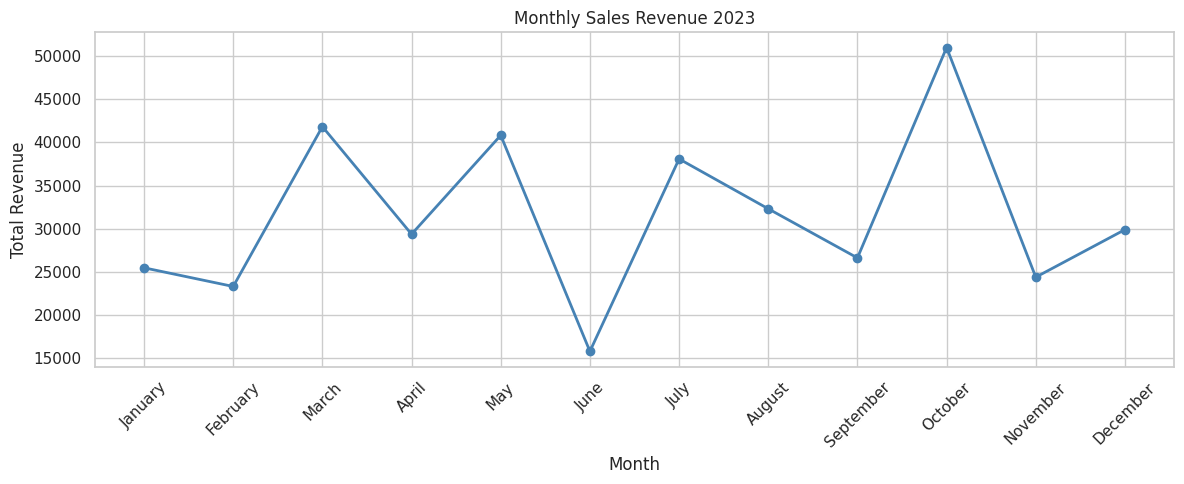

In [ ]:
monthly = df_clean.groupby('order_month_name')['total_amount'].sum()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly = monthly.reindex(month_order)

plt.figure(figsize=(12, 5))
plt.plot(monthly.index, monthly.values, marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Sales Revenue 2023')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

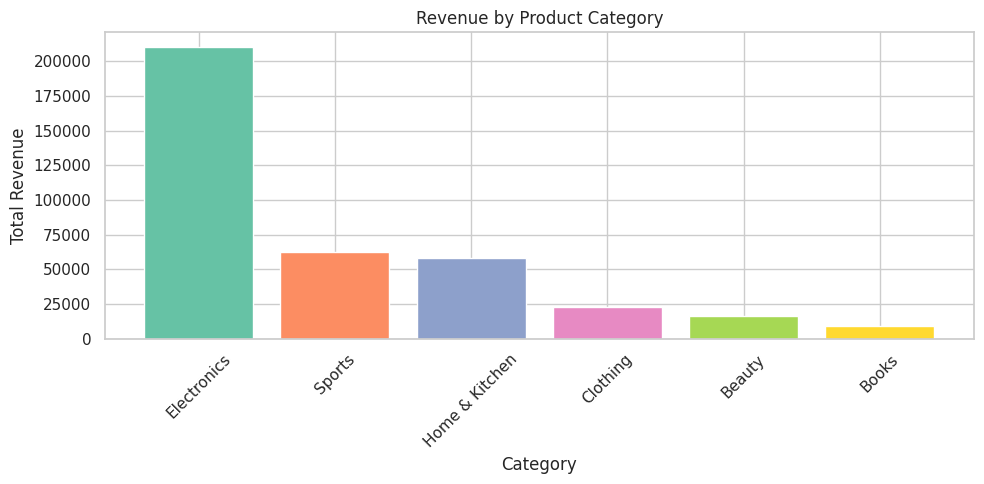

In [ ]:
cat_sales = df_clean.groupby('category')['total_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(cat_sales.index, cat_sales.values, color=sns.color_palette('Set2', len(cat_sales)))
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_10141/2191748287.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')


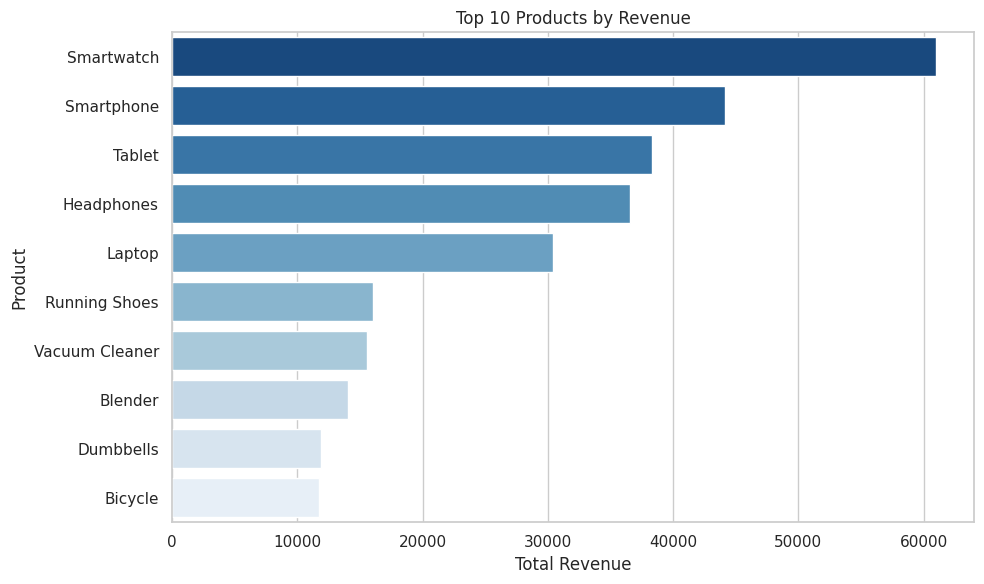

In [ ]:
top_products = df_clean.groupby('product_name')['total_amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

/tmp/ipykernel_10141/1227630450.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_sales.values, y=city_sales.index, palette='coolwarm')


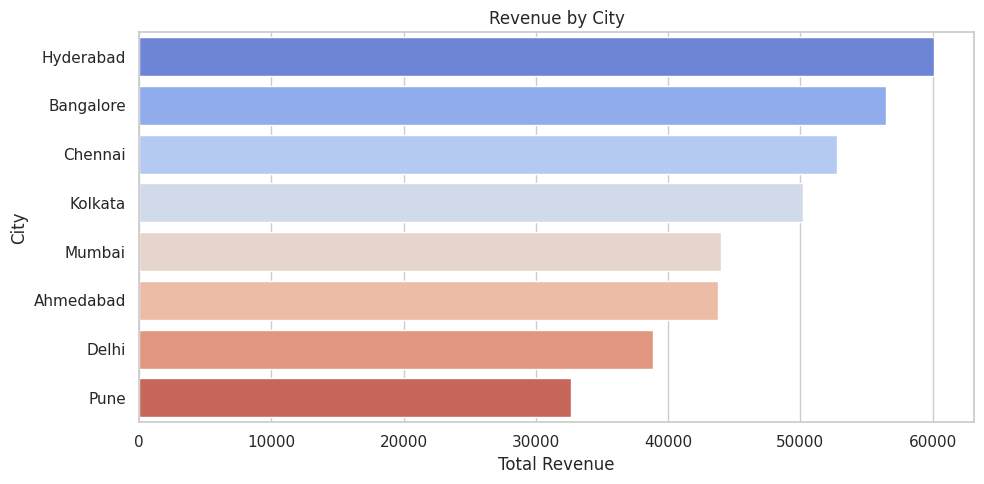

In [ ]:
city_sales = df_clean.groupby('city')['total_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=city_sales.values, y=city_sales.index, palette='coolwarm')
plt.title('Revenue by City')
plt.xlabel('Total Revenue')
plt.ylabel('City')
plt.tight_layout()
plt.show()

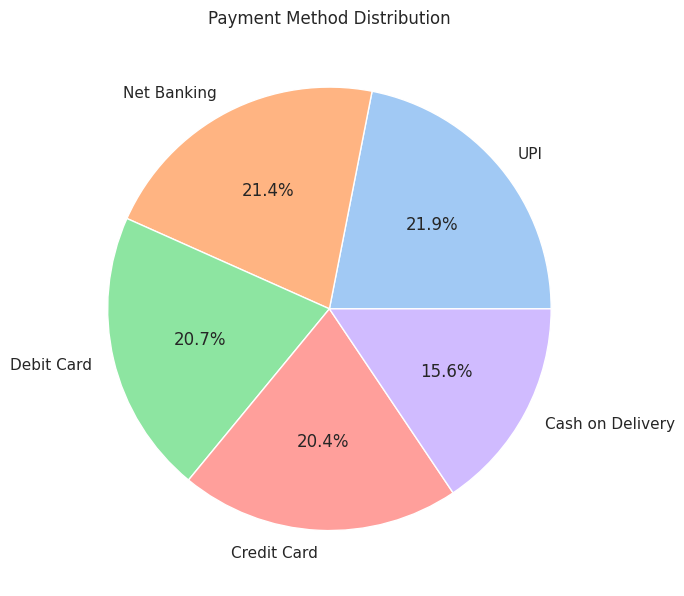

In [ ]:
payment = df_clean['payment_method'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(payment.values, labels=payment.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'))
plt.title('Payment Method Distribution')
plt.tight_layout()
plt.show()

/tmp/ipykernel_10141/1346732016.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg_counts.index, y=seg_counts.values, palette='Set3')


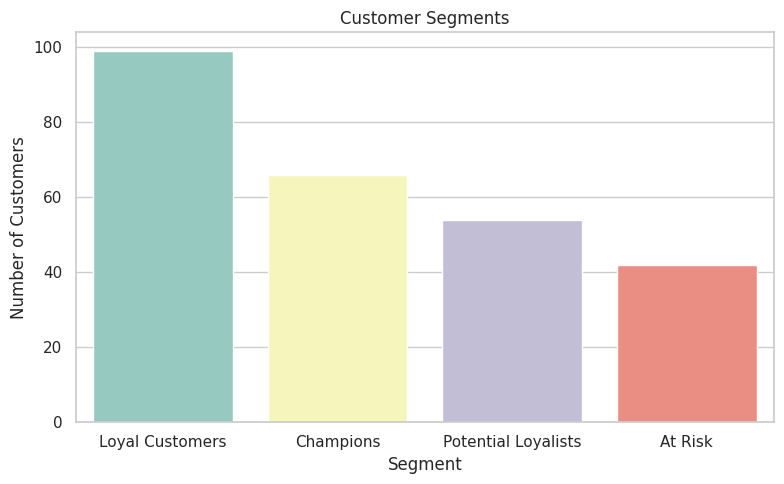

Segment
Loyal Customers        99
Champions              66
Potential Loyalists    54
At Risk                42
Name: count, dtype: int64


In [ ]:
snapshot_date = df_clean['order_date'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('customer_id').agg(
    Recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'count'),
    Monetary=('total_amount', 'sum')
).reset_index()

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segment(score):
    if score >= 10: return 'Champions'
    elif score >= 7: return 'Loyal Customers'
    elif score >= 5: return 'Potential Loyalists'
    else: return 'At Risk'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

seg_counts = rfm['Segment'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=seg_counts.index, y=seg_counts.values, palette='Set3')
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print(rfm['Segment'].value_counts())

In [ ]:
# Export files for Tableau
df_clean.to_csv('full_data.csv', index=False)

monthly_export = df_clean.groupby('order_month_name')['total_amount'].sum().reset_index()
monthly_export.to_csv('monthly_sales.csv', index=False)

category_export = df_clean.groupby('category')['total_amount'].sum().reset_index()
category_export.to_csv('category_sales.csv', index=False)

city_export = df_clean.groupby('city')['total_amount'].sum().reset_index()
city_export.to_csv('city_sales.csv', index=False)

print("All files exported!")
print("Files created: full_data.csv, monthly_sales.csv, category_sales.csv, city_sales.csv")

All files exported!
Files created: full_data.csv, monthly_sales.csv, category_sales.csv, city_sales.csv


In [ ]:
from google.colab import files
files.download('full_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>